# NAMA : PHILIPUS DIMA WIRA PRATOMO
# NIM : 203012520011
# Classification

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy import stats

from datetime import datetime

from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")

In [2]:
!pip install pycountry-convert


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


# Data Understanding

In [3]:
df = pd.read_csv("advertising (1).csv")

In [4]:
 df.sample(5)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
688,74.58,36,70701.31,230.52,Configurable mission-critical algorithm,East Carlos,0,Jamaica,2016-07-22 11:05:10,0
891,54.39,20,52563.22,171.90,Digitized content-based circuit,Richardshire,1,Guadeloupe,2016-02-29 18:06:21,1
843,74.61,38,71055.22,231.28,Networked impactful framework,East Christopher,1,South Africa,2016-04-06 23:10:40,0
889,54.08,36,53012.94,111.02,Innovative cohesive pricing structure,Philipberg,1,Mayotte,2016-06-02 04:14:37,1
60,85.61,27,47708.42,183.43,Customer-focused empowering ability,Lake Amy,0,Burundi,2016-04-30 08:07:13,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [6]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


# Data Preparation

In [7]:
data_preparation = df.copy()

## Check Imbalanced Data

<Axes: xlabel='Clicked on Ad', ylabel='count'>

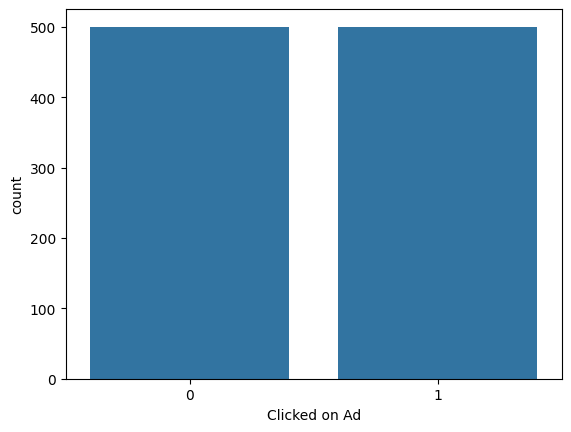

In [8]:
sns.countplot(x='Clicked on Ad', data=data_preparation)

## Checking for Null Values

In [9]:
misval1 = data_preparation.isnull().sum()
print(misval1.sort_values(ascending=False))

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64


## Checking for Data Duplicates

In [10]:
data_preparation.duplicated().sum()

np.int64(0)

## Feature Engineering

In [11]:
feature_list = [
    'City',
    'Country',
    'Ad Topic Line',
    'Timestamp'
]

unique_count = pd.DataFrame({
    'Feature': feature_list,
    'Unique Count': [data_preparation[col].nunique() for col in feature_list]
})

unique_count

,Feature,Unique Count
0,City,969
1,Country,237
2,Ad Topic Line,1000
3,Timestamp,1000


In [12]:
data_preparation['Timestamp'] = pd.to_datetime(data_preparation['Timestamp'], errors='coerce')

data_preparation['Jam Kerja'] = data_preparation['Timestamp'].dt.hour.apply(
    lambda x: "Office Hour" if pd.notna(x) and 9 <= x < 17 else "After Office Hour"
)

data_preparation['DayName'] = data_preparation['Timestamp'].dt.day_name()
data_preparation['MonthName'] = data_preparation['Timestamp'].dt.month_name()

data_preparation.rename(columns={'Male': 'Gender'}, inplace=True)

data_preparation['Gender'] = data_preparation['Gender'].map({
    0: 'Female',
    1: 'Male'
})

data_preparation['Ad_Length'] = data_preparation['Ad Topic Line'].apply(len)

In [13]:
import pycountry_convert as pc

def country_to_continent(country_name):
    try:
        country_code = pc.country_name_to_country_alpha2(
            country_name,
            cn_name_format="default"
        )

        continent_code = pc.country_alpha2_to_continent_code(country_code)

        continent_dict = {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "SA": "South America",
            "OC": "Oceania"
        }

        return continent_dict[continent_code]

    except:
        return "Unknown"

data_preparation['Continent'] = data_preparation['Country'].apply(country_to_continent)

In [14]:
feature_list = [
    'Jam Kerja',
    'DayName',
    'MonthName',
    'Ad_Length',
    'Continent'
]

unique_count = pd.DataFrame({
    'Feature': feature_list,
    'Unique Count': [data_preparation[col].nunique() for col in feature_list]
})

unique_count

,Feature,Unique Count
0,Jam Kerja,2
1,DayName,7
2,MonthName,7
3,Ad_Length,35
4,Continent,7


## Checking Outlier

In [15]:
from scipy.stats import zscore
import numpy as np
import pandas as pd

num = data_preparation.select_dtypes(include=[np.number])

z_scores = pd.DataFrame(zscore(num), columns=num.columns)

for col in num.columns.drop('Clicked on Ad'):
    outliers = data_preparation[np.abs(z_scores[col]) > 3]

    print(f"\n=== {col} ===")
    print(f"Jumlah outlier: {len(outliers)}")

    if len(outliers) > 0:
        print(outliers[[col]].head())


=== Daily Time Spent on Site ===
Jumlah outlier: 0

=== Age ===
Jumlah outlier: 0

=== Area Income ===
Jumlah outlier: 3
     Area Income
692     14548.06
768     13996.50
778     14775.50

=== Daily Internet Usage ===
Jumlah outlier: 0

=== Ad_Length ===
Jumlah outlier: 4
     Ad_Length
204         51
298         55
467         51
519         54


# Exploratory Data Analysis

In [16]:
data_eda = data_preparation.copy()

In [17]:
num = data_eda.select_dtypes(include=[np.number])
cat = data_eda.select_dtypes(include=[object])

## Numerical Analysis

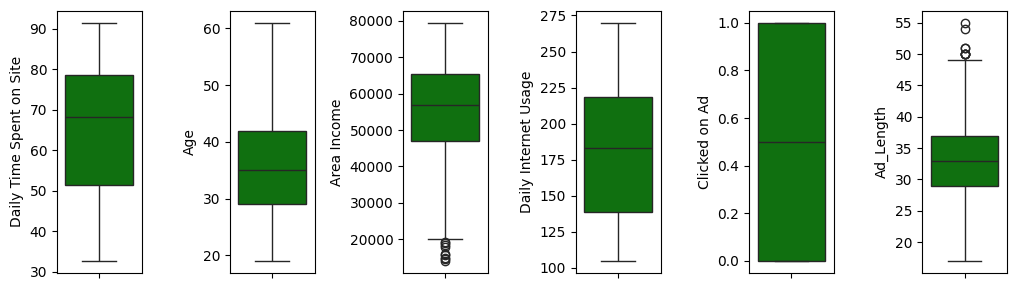

In [18]:
num_list = list(num)
plt.figure(figsize=(12, 3))
for i in range(0, len(num_list)):
    plt.subplot(int(len(num_list)/4), 7, i+1)
    sns.boxplot(y=data_eda[num_list[i]],color='green',orient='v')
    plt.tight_layout()

/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/2109934348.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Clicked on Ad', y=col, data=data_eda, palette='Set2')
/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/2109934348.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Clicked on Ad', y=col, data=data_eda, palette='Set2')
/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/2109934348.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Clicked on Ad', y=col, data=data_eda, palet

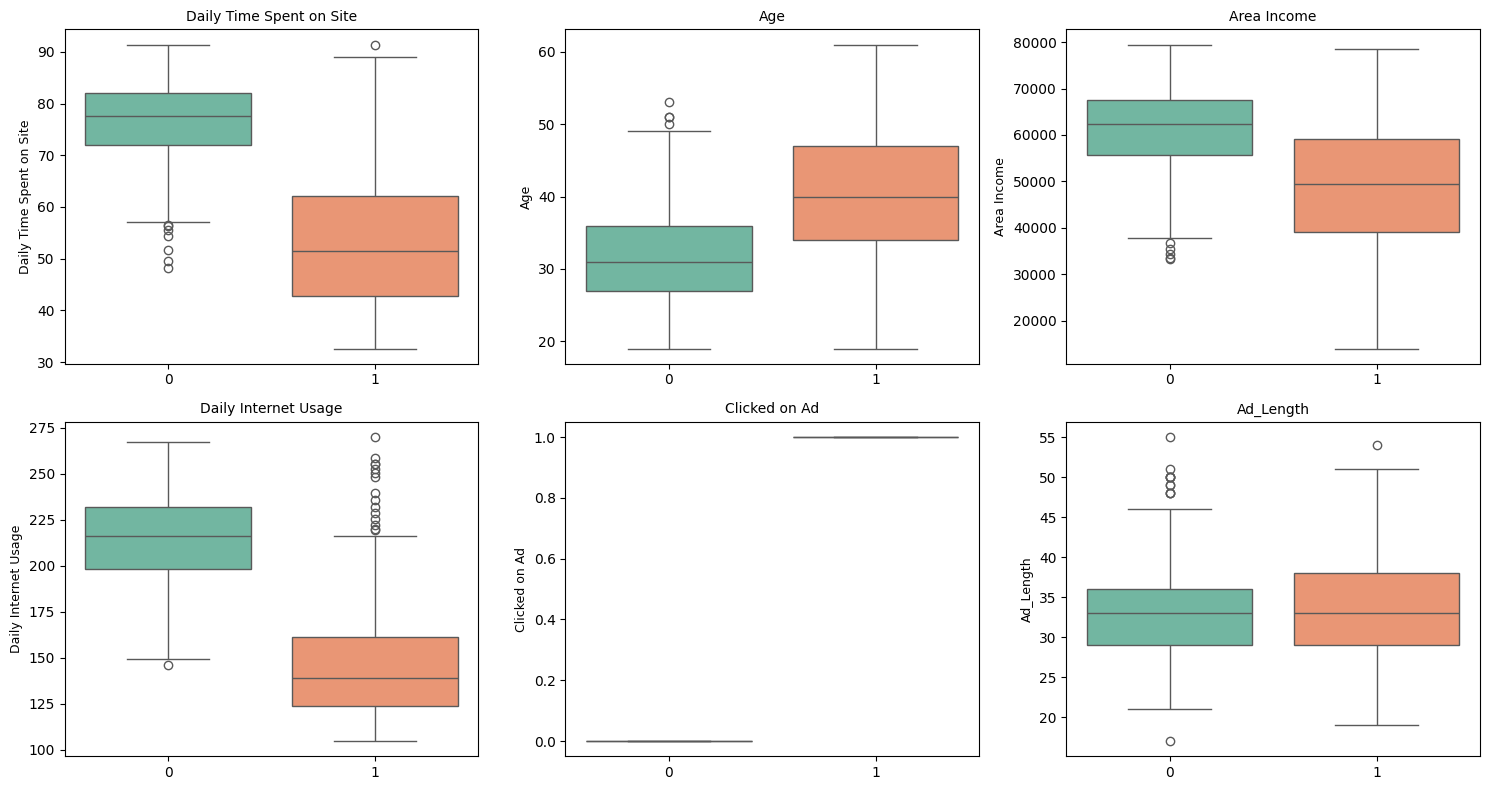

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_list = list(num)

n_cols = 3
n_rows = math.ceil(len(num_list) / n_cols)

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(num_list):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x='Clicked on Ad', y=col, data=data_eda, palette='Set2')
    plt.title(col, fontsize=10)
    plt.xlabel('')
    plt.ylabel(col, fontsize=9)

plt.tight_layout()
plt.show()

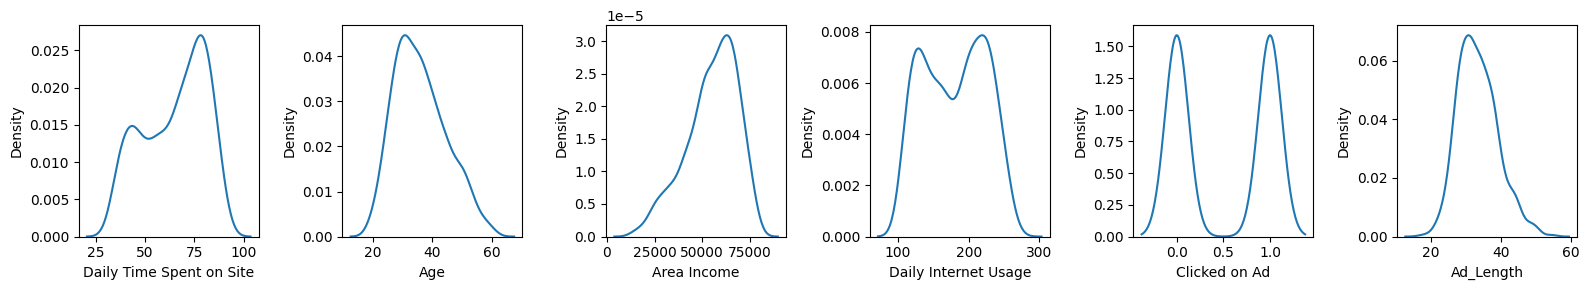

In [20]:
num_list = list(num)
plt.figure(figsize=(16, 3))
for i in range(0, len(num_list)):
    plt.subplot(int(len(num_list)/4), 6, i+1)
    sns.kdeplot(x=data_eda[num_list[i]])
    plt.xlabel(num_list[i])
    plt.tight_layout()

/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/3470775497.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


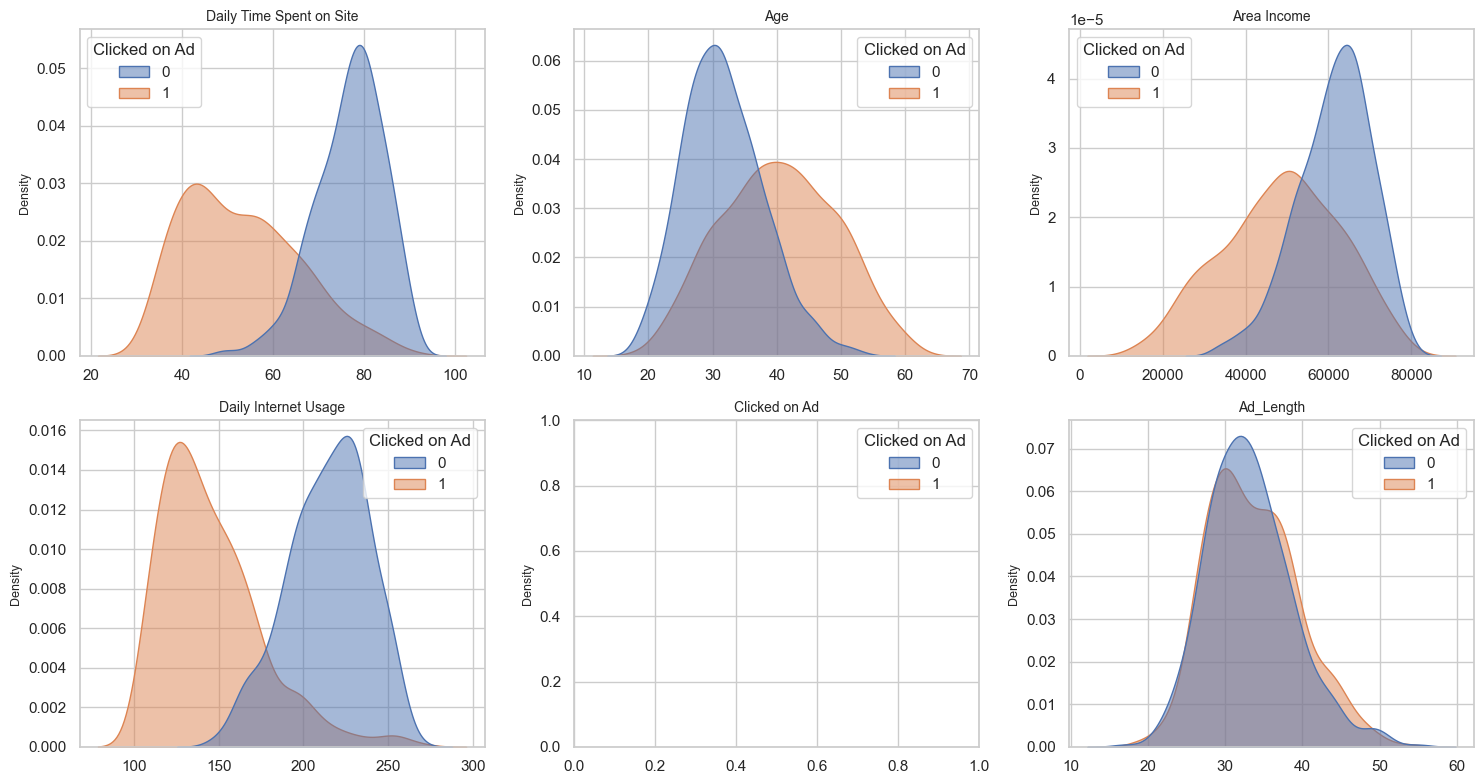

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_list = list(num)

n_cols = 3
n_rows = math.ceil(len(num_list) / n_cols)

plt.figure(figsize=(15, 4 * n_rows))
sns.set(style="whitegrid")

for i, col in enumerate(num_list):
    plt.subplot(n_rows, n_cols, i+1)
    sns.kdeplot(
        data=data_eda,
        x=col,
        hue='Clicked on Ad',
        fill=True,
        common_norm=False,
        alpha=0.5
    )
    plt.title(col, fontsize=10)
    plt.xlabel('')
    plt.ylabel('Density', fontsize=9)

plt.tight_layout()
plt.show()

## Categorical Analysis

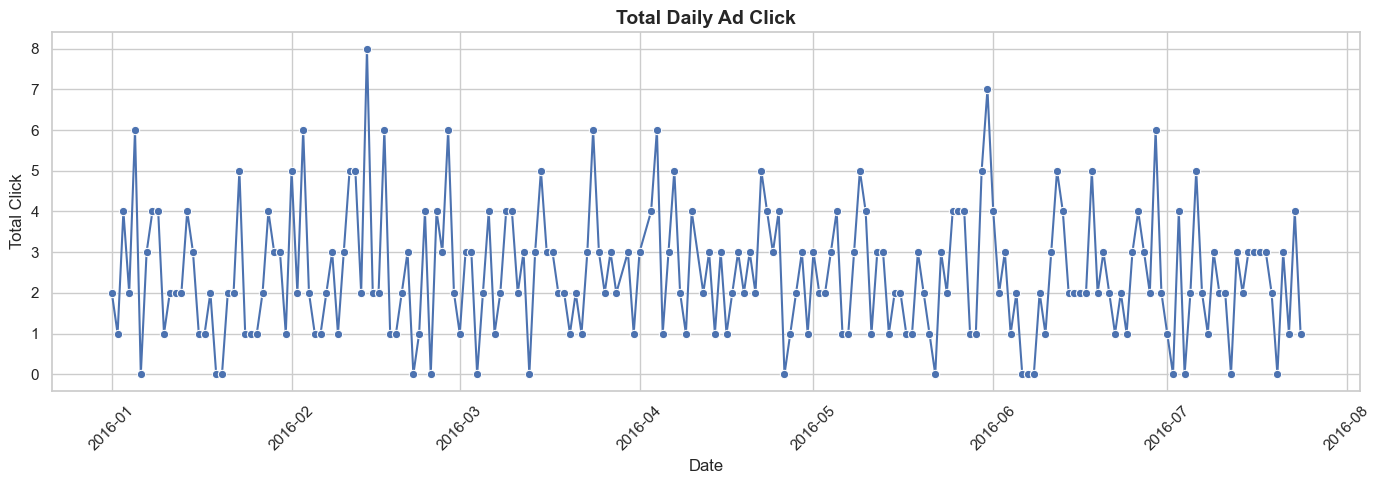

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# TIMESTAMP TO DATE
# =========================

data_eda['Date'] = pd.to_datetime(
    data_eda['Timestamp']
).dt.date

# =========================
# GROUP BY DATE
# =========================

daily_click = (
    data_eda.groupby('Date')['Clicked on Ad']
    .sum()
    .reset_index()
)

# =========================
# LINE PLOT
# =========================

plt.figure(figsize=(14,5))

sns.set_style("whitegrid")

sns.lineplot(
    data=daily_click,
    x='Date',
    y='Clicked on Ad',
    marker='o'
)

plt.title(
    'Total Daily Ad Click',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Total Click')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/3511875596.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/3511875596.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/3511875596.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/3511875596.py:29: FutureWarning: 

Passing `palette` without assigning `hue` 

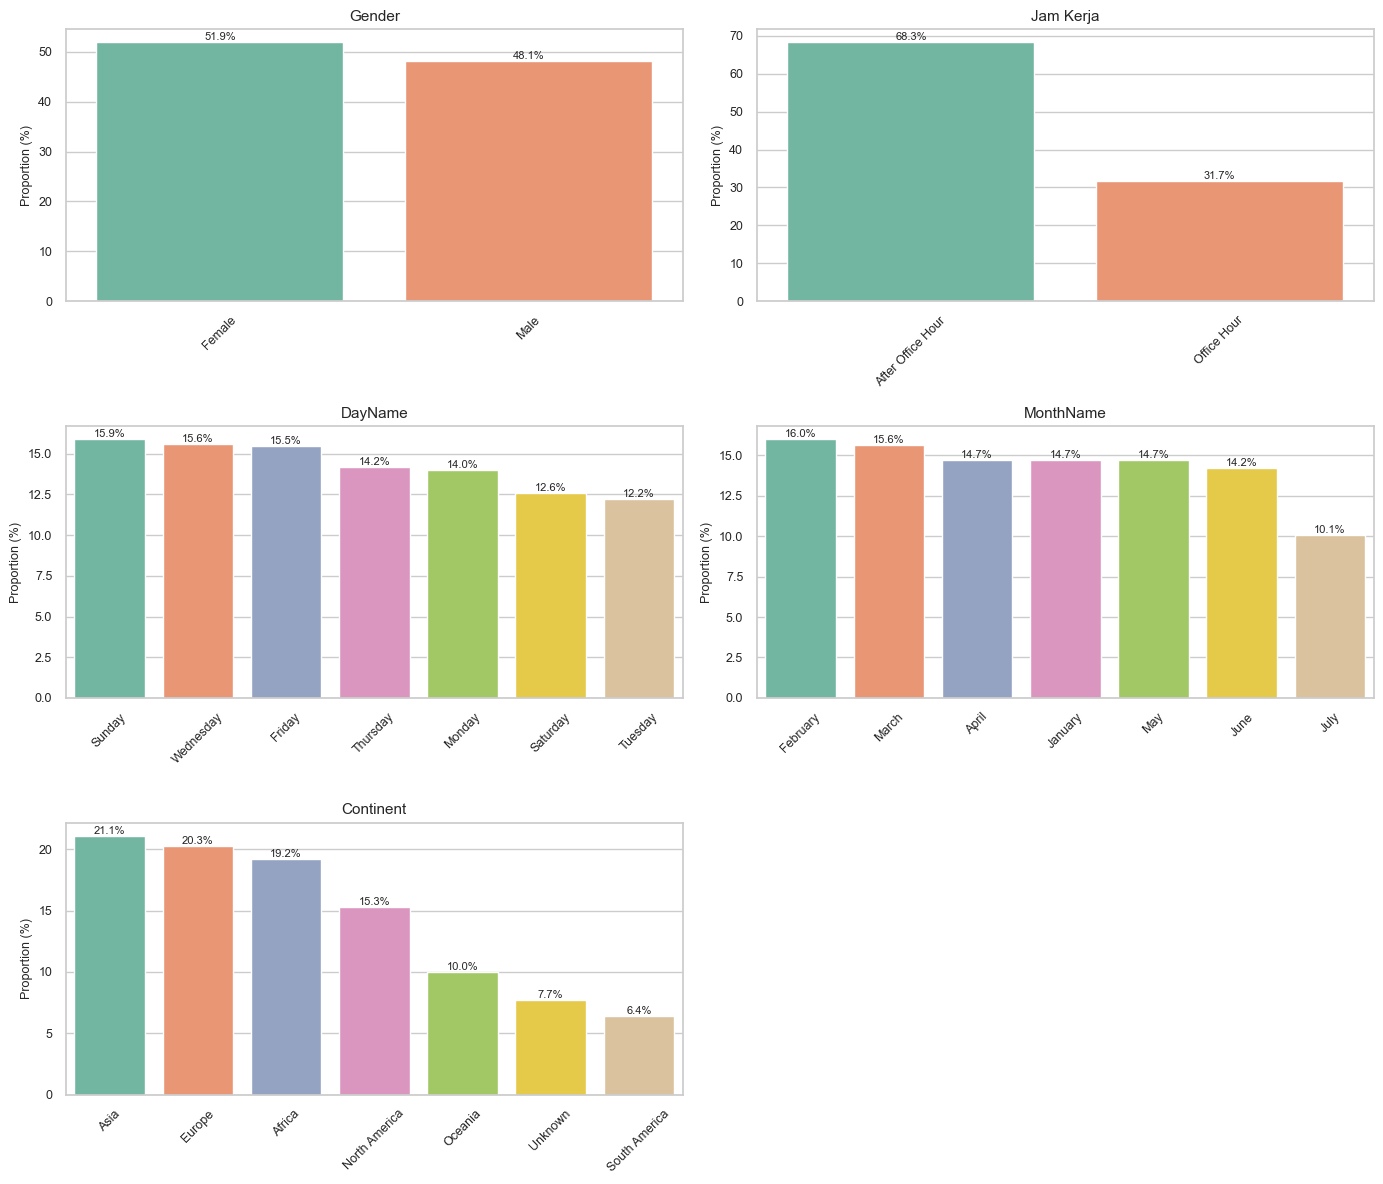

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

cat_new = cat.drop(columns=['Ad Topic Line','City','Country'])
cat_list = list(cat_new)

n_cols = 2
n_rows = math.ceil(len(cat_list) / n_cols)

plt.figure(figsize=(14, 4 * n_rows))
sns.set(style="whitegrid")

for i, col in enumerate(cat_list):
    plt.subplot(n_rows, n_cols, i+1)

    df_group = (
        data_eda.groupby(col)
        .size()
        .reset_index(name='Total')
    )

    df_group['Proportion'] = (
        df_group['Total'] / df_group['Total'].sum() * 100
    )

    df_group = df_group.sort_values(by='Proportion', ascending=False)

    ax = sns.barplot(
        data=df_group,
        x=col,
        y='Proportion',
        palette='Set2'
    )

    plt.title(col, fontsize=11)
    plt.xlabel('')
    plt.ylabel('Proportion (%)', fontsize=9)

    plt.xticks(rotation=45, fontsize=9)
    plt.yticks(fontsize=9)

    # annotasi persen
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.show()

/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/2822080266.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/2822080266.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/2822080266.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/2822080266.py:22: FutureWarning: 

Passing `palette` without assigni

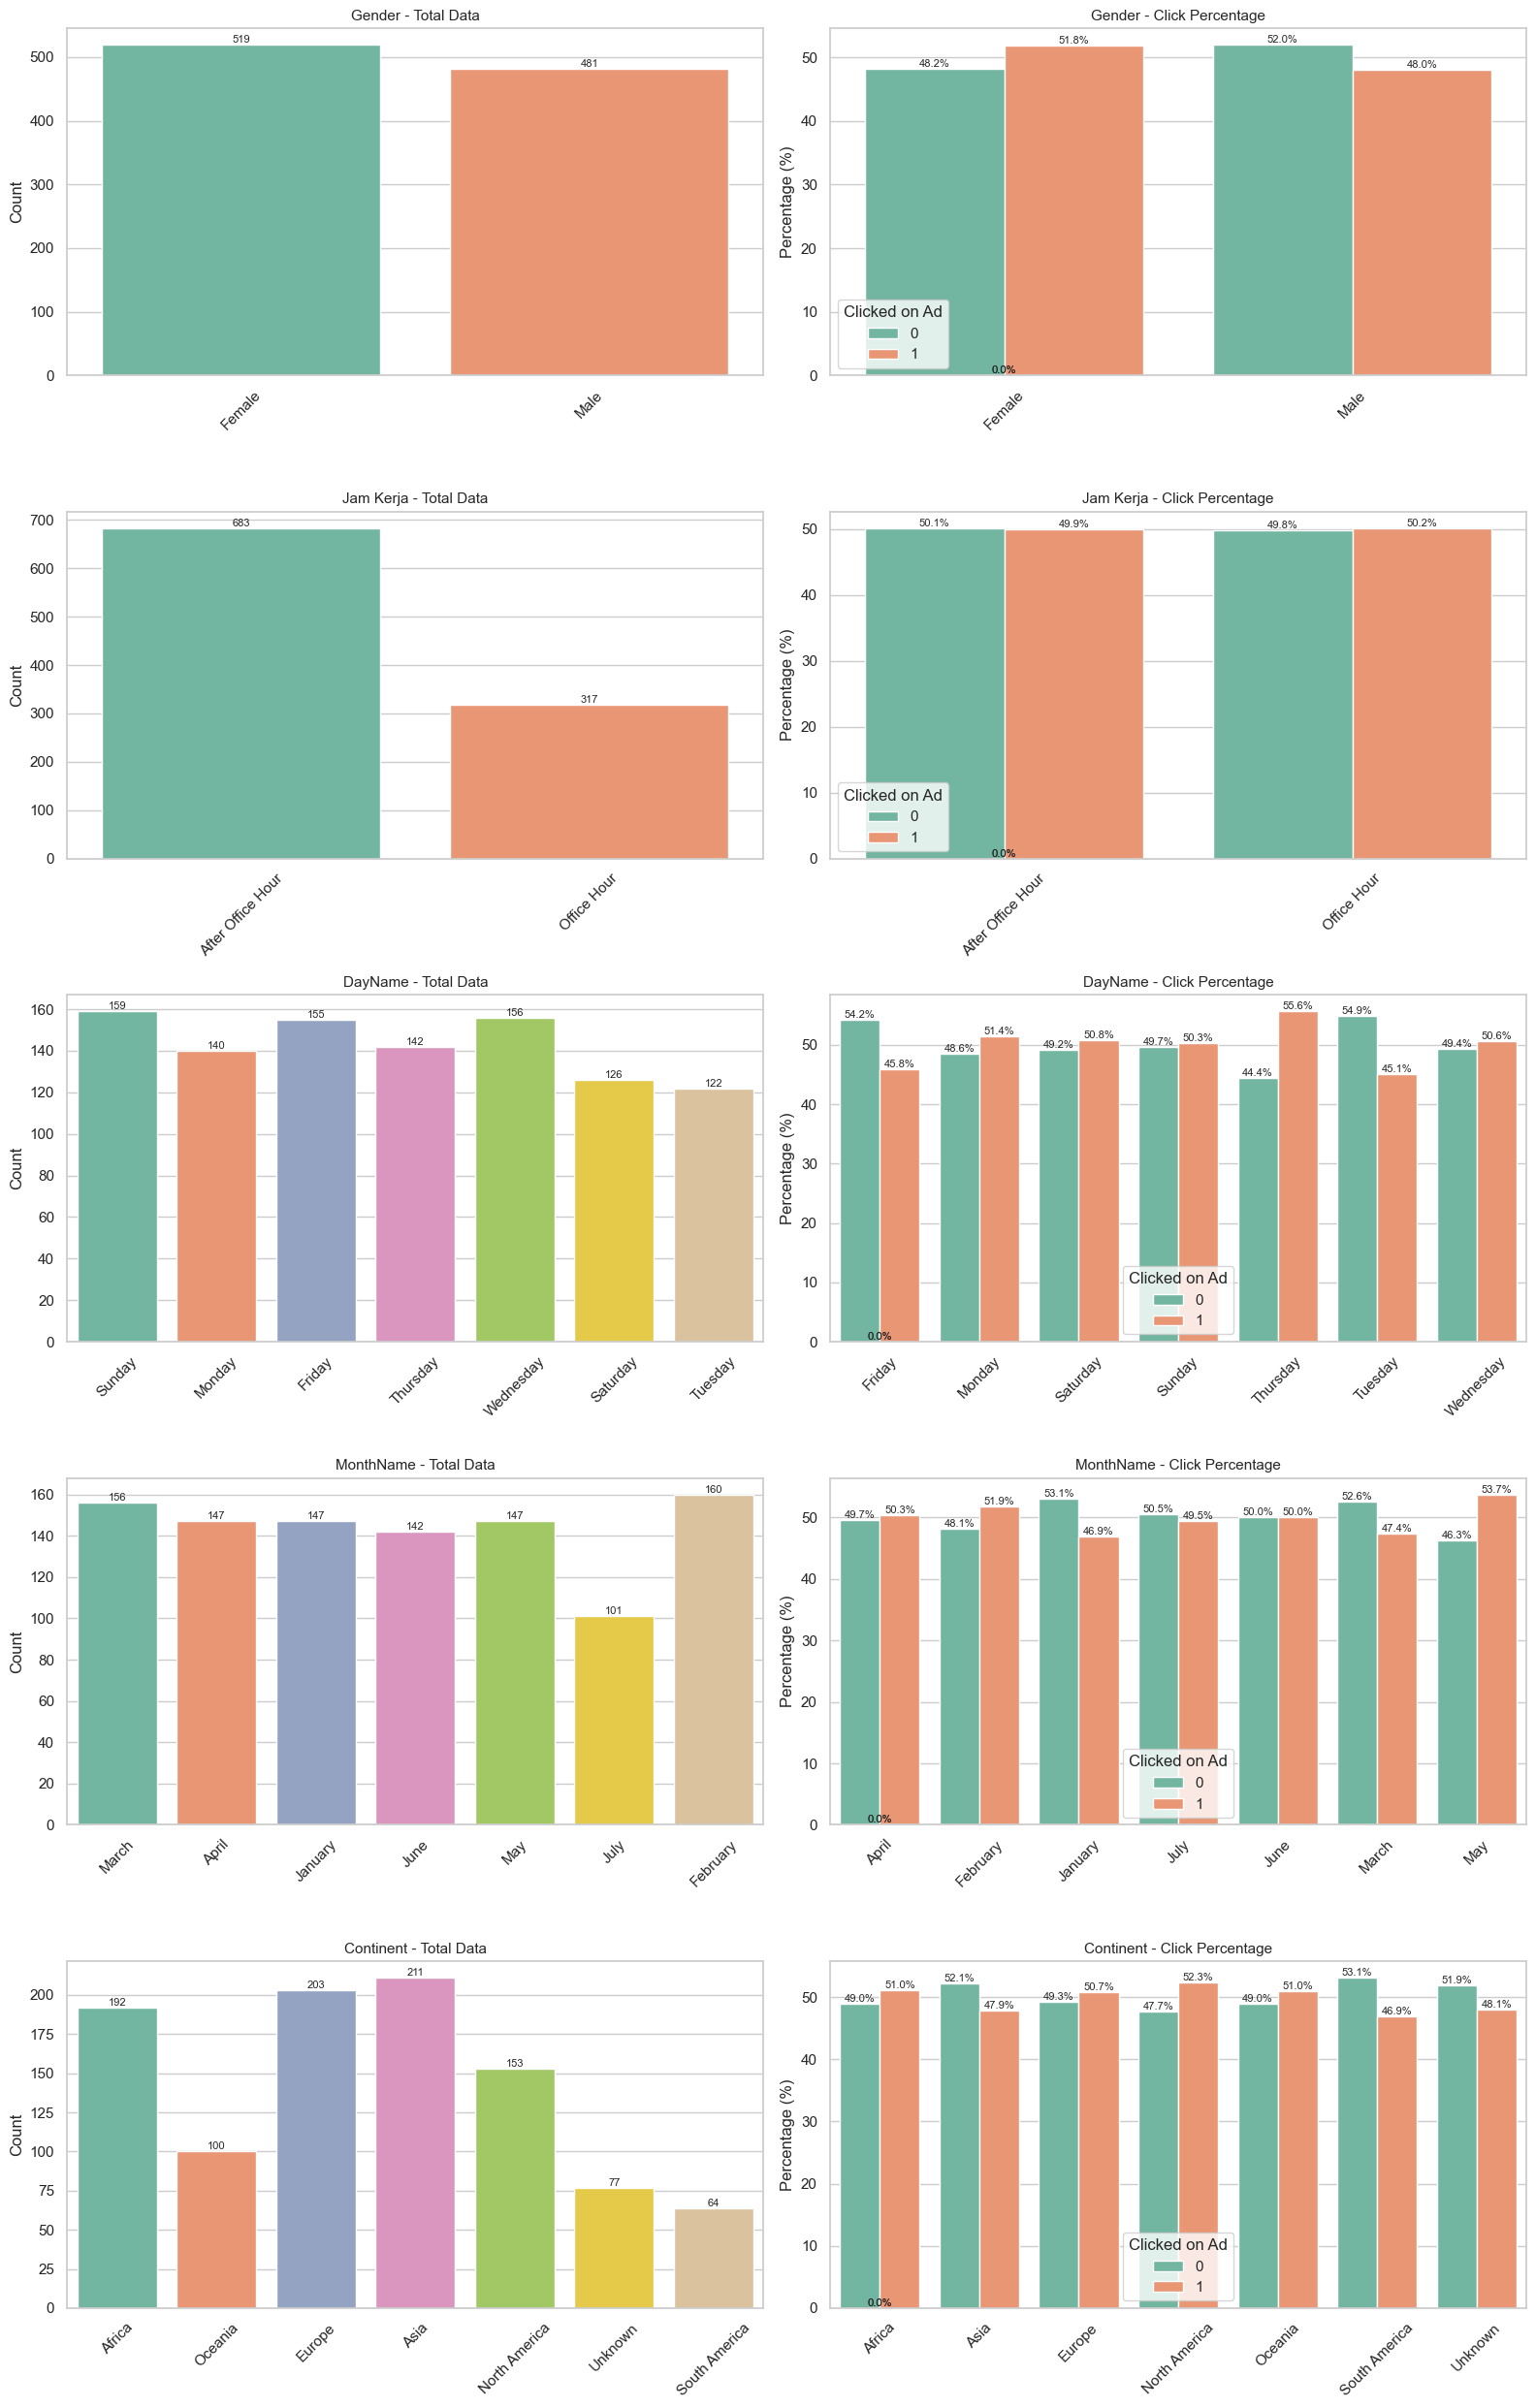

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

cat_new = cat.drop(columns=['Ad Topic Line','City','Country'])
cat_list = list(cat_new)

n_cols = 2
n_rows = len(cat_list)

plt.figure(figsize=(16, 5 * n_rows))
sns.set(style="whitegrid")

for i, col in enumerate(cat_list):

    # =========================
    # LEFT = COUNT DISTRIBUTION
    # =========================
    plt.subplot(n_rows, n_cols, i*2 + 1)

    ax1 = sns.countplot(
        data=data_eda,
        x=col,
        palette='Set2'
    )

    plt.title(f'{col} - Total Data', fontsize=11)
    plt.xlabel('')
    plt.ylabel('Count')

    plt.xticks(rotation=45)

    # annotasi jumlah
    for p in ax1.patches:
        height = p.get_height()

        ax1.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom',
            fontsize=8
        )

    # =========================
    # RIGHT = TARGET PERCENTAGE
    # =========================
    plt.subplot(n_rows, n_cols, i*2 + 2)

    df_group = (
        data_eda.groupby([col, 'Clicked on Ad'])
        .size()
        .reset_index(name='Count')
    )

    df_group['Percentage'] = df_group.groupby(col)['Count'].transform(
        lambda x: x / x.sum() * 100
    )

    ax2 = sns.barplot(
        data=df_group,
        x=col,
        y='Percentage',
        hue='Clicked on Ad',
        palette='Set2'
    )

    plt.title(f'{col} - Click Percentage', fontsize=11)
    plt.xlabel('')
    plt.ylabel('Percentage (%)')

    plt.xticks(rotation=45)

    # annotasi persen
    for p in ax2.patches:
        height = p.get_height()

        if not np.isnan(height):
            ax2.annotate(
                f'{height:.1f}%',
                (p.get_x() + p.get_width()/2, height),
                ha='center',
                va='bottom',
                fontsize=8
            )

plt.tight_layout()
plt.show()

/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/336747925.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/336747925.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/336747925.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/336747925.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated

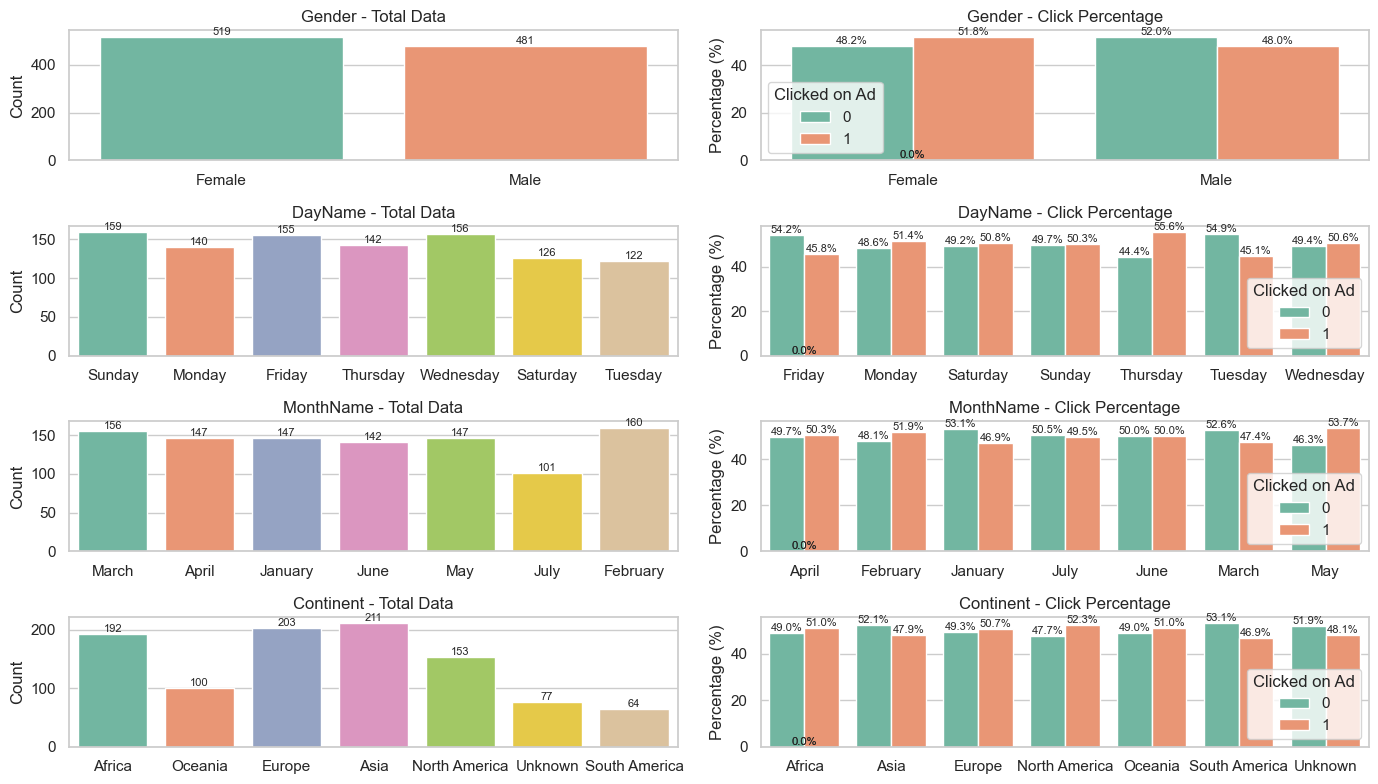

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# fitur yang dipakai
cat_list = ['Gender', 'DayName', 'MonthName', 'Continent']

sns.set(style="whitegrid")

fig, axes = plt.subplots(
    nrows=len(cat_list),
    ncols=2,
    figsize=(14, 8)
)

for i, col in enumerate(cat_list):

    # ====================================
    # LEFT : TOTAL DISTRIBUTION
    # ====================================
    ax1 = axes[i, 0]

    sns.countplot(
        data=data_eda,
        x=col,
        palette='Set2',
        ax=ax1
    )

    ax1.set_title(f'{col} - Total Data')
    ax1.set_xlabel('')
    ax1.set_ylabel('Count')

    # annotation count
    for p in ax1.patches:

        height = p.get_height()

        ax1.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom',
            fontsize=8
        )

    # ====================================
    # RIGHT : CLICK PERCENTAGE
    # ====================================
    ax2 = axes[i, 1]

    df_group = (
        data_eda.groupby([col, 'Clicked on Ad'])
        .size()
        .reset_index(name='Count')
    )

    df_group['Percentage'] = (
        df_group.groupby(col)['Count']
        .transform(lambda x: x / x.sum() * 100)
    )

    sns.barplot(
        data=df_group,
        x=col,
        y='Percentage',
        hue='Clicked on Ad',
        palette='Set2',
        ax=ax2
    )

    ax2.set_title(f'{col} - Click Percentage')
    ax2.set_xlabel('')
    ax2.set_ylabel('Percentage (%)')

    # annotation percentage
    for p in ax2.patches:

        height = p.get_height()

        if not np.isnan(height):

            ax2.annotate(
                f'{height:.1f}%',
                (p.get_x() + p.get_width()/2, height),
                ha='center',
                va='bottom',
                fontsize=8
            )

plt.tight_layout()
plt.show()

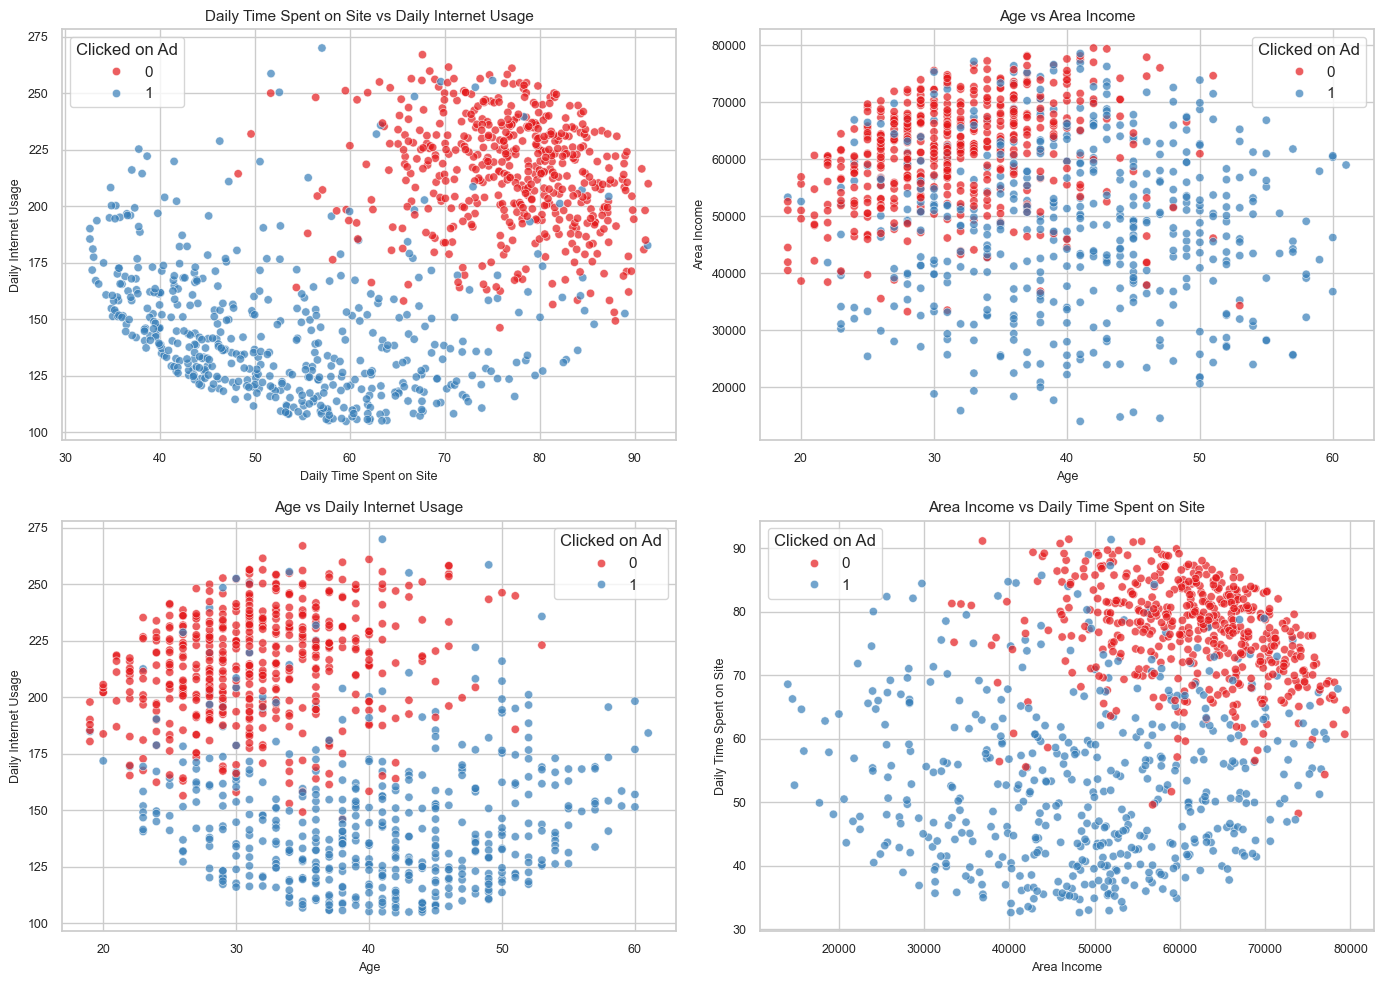

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

scatter_cols = [
    ('Daily Time Spent on Site', 'Daily Internet Usage'),
    ('Age', 'Area Income'),
    ('Age', 'Daily Internet Usage'),
    ('Area Income', 'Daily Time Spent on Site')
]

n_cols = 2
n_rows = math.ceil(len(scatter_cols) / n_cols)

plt.figure(figsize=(14, 5 * n_rows))
sns.set(style="whitegrid")

for i, (x_col, y_col) in enumerate(scatter_cols):
    plt.subplot(n_rows, n_cols, i+1)

    sns.scatterplot(
        data=data_eda,
        x=x_col,
        y=y_col,
        hue='Clicked on Ad',
        palette='Set1',
        alpha=0.7
    )

    plt.title(f'{x_col} vs {y_col}', fontsize=11)
    plt.xlabel(x_col, fontsize=9)
    plt.ylabel(y_col, fontsize=9)

    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

## Bivariate Analysis

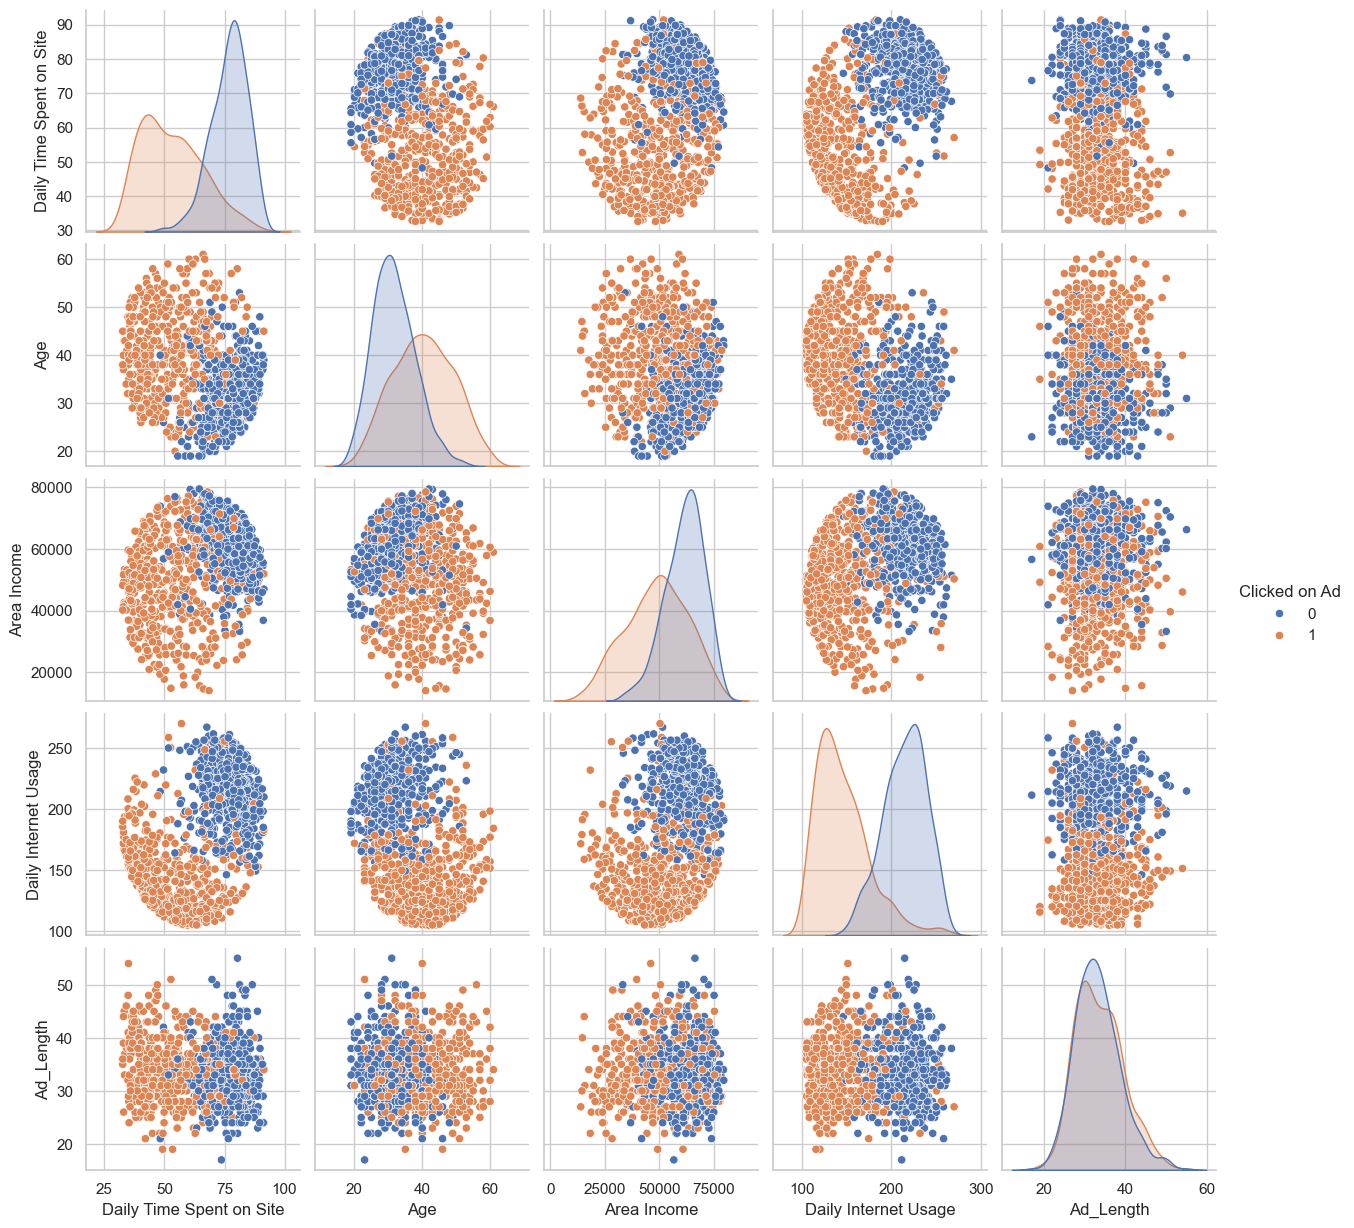

In [27]:
sns.pairplot(num,hue='Clicked on Ad')

## Corellation Analysis

In [28]:
data_multiva = data_eda.copy()

In [29]:
data_multiva = data_multiva.drop(columns=['Ad Topic Line','City','Country'])

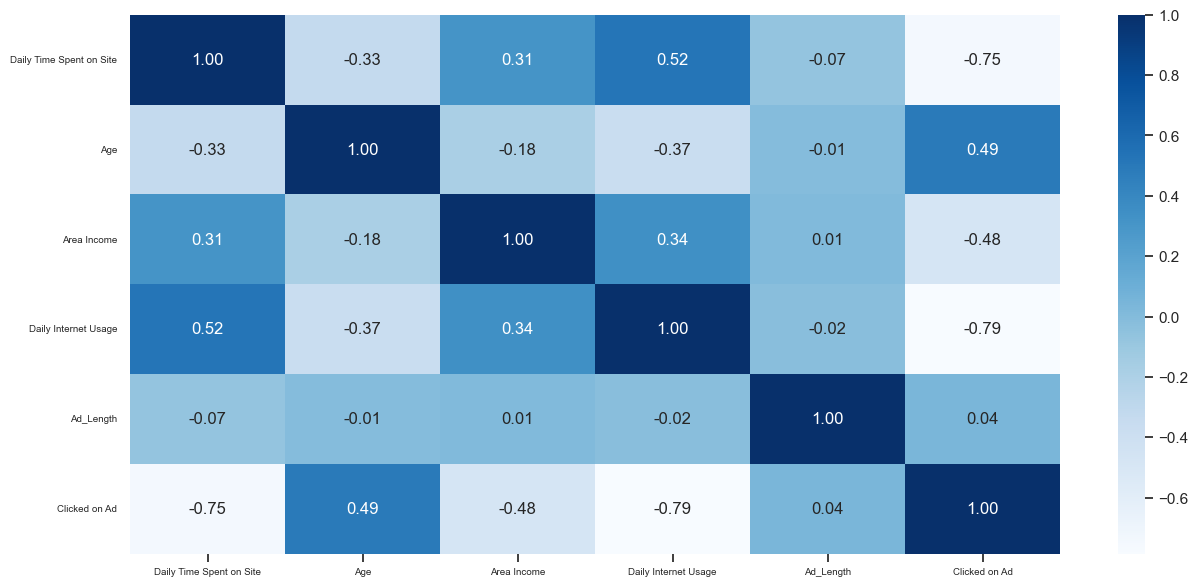

In [30]:
num_corr = data_multiva[[
    'Daily Time Spent on Site',
    'Age',
    'Area Income',
    'Daily Internet Usage',
    'Ad_Length',
    'Clicked on Ad'
]]

correlation_matrix = num_corr.corr()
plt.figure(figsize=(15, 7))
ax = sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
ax.set_xticklabels(ax.get_xticklabels(), size=7)
ax.set_yticklabels(ax.get_yticklabels(), size=7)
ax.xaxis.tick_bottom()

/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/1212993490.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
/var/folders/y1/1zh043m97g38bfgmn7cp0r3w0000gn/T/ipykernel_20186/1212993490.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


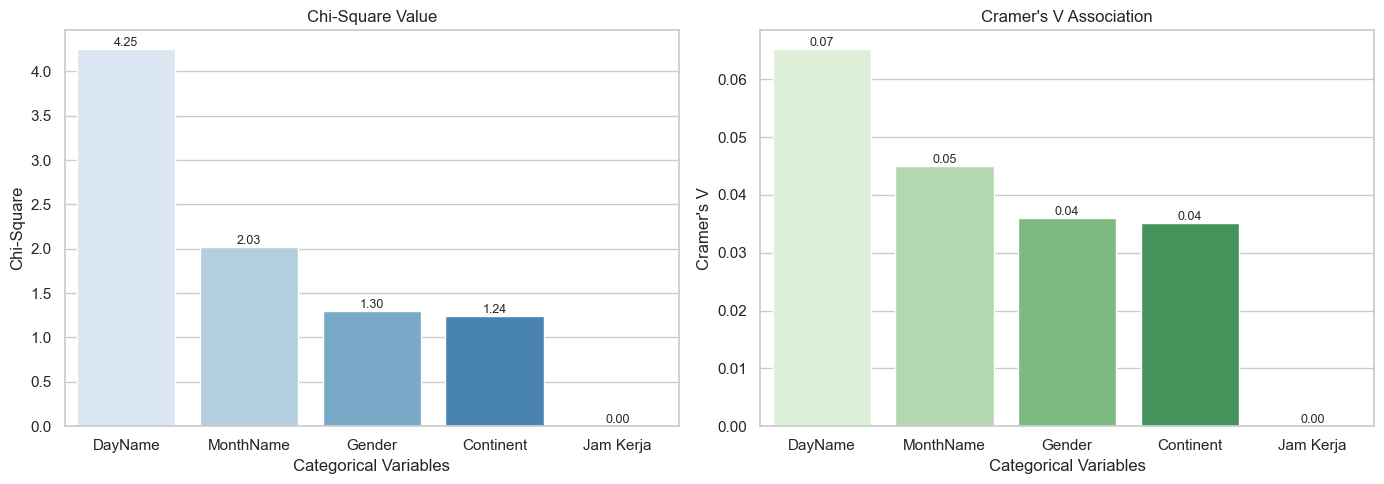

    Variable  ChiSquare    PValue  CramersV
2    DayName   4.251429  0.642693  0.065203
3  MonthName   2.026110  0.917282  0.045012
0     Gender   1.297874  0.254602  0.036026
4  Continent   1.238699  0.974930  0.035195
1  Jam Kerja   0.000000  1.000000  0.000000


In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

cat_cols = [
    'Gender',
    'Jam Kerja',
    'DayName',
    'MonthName',
    'Continent'
]

results = []

for col in cat_cols:

    contingency_table = pd.crosstab(
        data_eda[col],
        data_eda['Clicked on Ad']
    )

    # Chi-Square
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Total sample
    n = contingency_table.sum().sum()

    # Cramer's V
    cramers_v = np.sqrt(
        chi2 / (n * (min(contingency_table.shape) - 1))
    )

    results.append({
        'Variable': col,
        'ChiSquare': chi2,
        'PValue': p,
        'CramersV': cramers_v
    })

# dataframe hasil
association_df = pd.DataFrame(results)

# sorting berdasarkan Cramer's V
association_df = association_df.sort_values(
    by='CramersV',
    ascending=False
)

# =========================
# VISUALISASI
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =========================
# CHI-SQUARE BARPLOT
# =========================

ax1 = sns.barplot(
    data=association_df,
    x='Variable',
    y='ChiSquare',
    palette='Blues',
    ax=axes[0]
)

axes[0].set_title('Chi-Square Value')
axes[0].set_xlabel('Categorical Variables')
axes[0].set_ylabel('Chi-Square')

for p in ax1.patches:

    height = p.get_height()

    ax1.annotate(
        f'{height:.2f}',
        (p.get_x() + p.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=9
    )

# =========================
# CRAMER'S V BARPLOT
# =========================

ax2 = sns.barplot(
    data=association_df,
    x='Variable',
    y='CramersV',
    palette='Greens',
    ax=axes[1]
)

axes[1].set_title("Cramer's V Association")
axes[1].set_xlabel('Categorical Variables')
axes[1].set_ylabel("Cramer's V")

for p in ax2.patches:

    height = p.get_height()

    ax2.annotate(
        f'{height:.2f}',
        (p.get_x() + p.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

# tabel hasil
print(association_df)

In [32]:
data_multiva.corr(numeric_only=True)['Clicked on Ad'].sort_values(ascending=False)

Clicked on Ad               1.000000
Age                         0.492531
Ad_Length                   0.040425
Area Income                -0.476255
Daily Time Spent on Site   -0.748117
Daily Internet Usage       -0.786539
Name: Clicked on Ad, dtype: float64

# Modelling

In [55]:
data_model = data_eda.copy()

In [56]:
data_model = data_model.drop(columns=['Timestamp','Ad Topic Line','City','Country','Jam Kerja','Ad_Length','Date'])

In [57]:
data_model.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Gender,Clicked on Ad,DayName,MonthName,Continent
0,68.95,35,61833.90,256.09,Female,0,Sunday,March,Africa
1,80.23,31,68441.85,193.77,Male,0,Monday,April,Oceania
2,69.47,26,59785.94,236.50,Female,0,Sunday,March,Europe
3,74.15,29,54806.18,245.89,Male,0,Sunday,January,Europe
4,68.37,35,73889.99,225.58,Female,0,Friday,June,Europe


## Split Feature and Target

In [58]:
X = data_model.drop(columns=['Clicked on Ad'])
y = data_model['Clicked on Ad']

## Split data Train and Test

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## One Hot Encoding

In [60]:
categorical_cols = ['Gender', 'DayName', 'MonthName', 'Continent']

X_train = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True
)

In [61]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

## Normalisasi Data

In [62]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_cols = ['Age', 'Daily Time Spent on Site', 'Daily Internet Usage', 'Area Income']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## Balanced Target on Data Training and Test

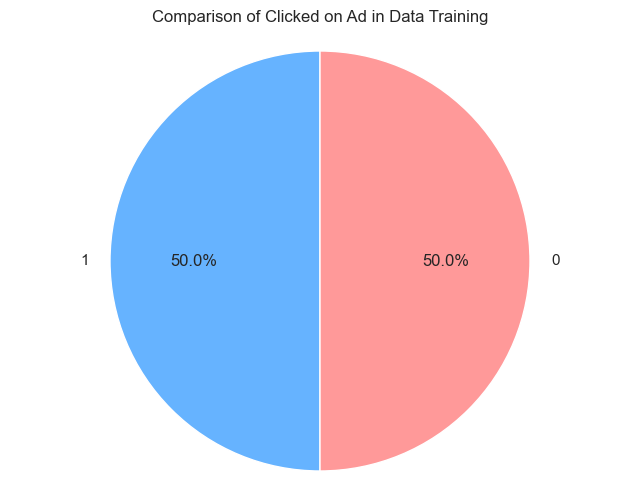

In [63]:
sns.set(style="darkgrid")
plt.figure(figsize=(8, 6))
df_checkimbalance_train = y_train.value_counts()
labels = df_checkimbalance_train.index
plt.pie(df_checkimbalance_train, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title("Comparison of Clicked on Ad in Data Training")
plt.axis('equal')
plt.show()

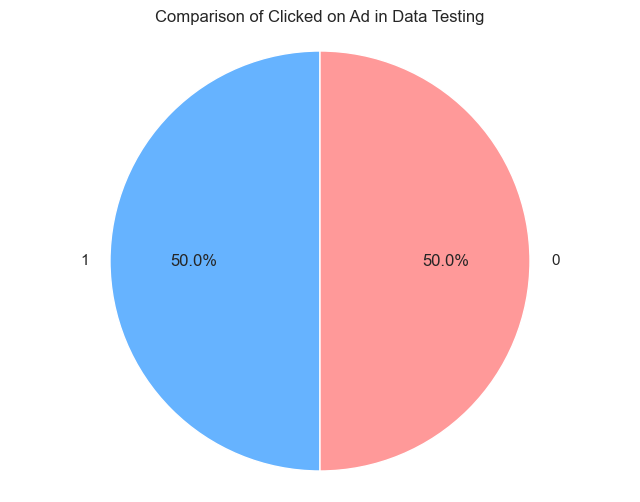

In [64]:
sns.set(style="darkgrid")
plt.figure(figsize=(8, 6))
df_checkimbalance_test = y_test.value_counts()
labels = df_checkimbalance_test.index
plt.pie(df_checkimbalance_test, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title("Comparison of Clicked on Ad in Data Testing")
plt.axis('equal')
plt.show()

# Baseline Modelling & Feature Selection

In [65]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    import pandas as pd
    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
        confusion_matrix
    )
    from sklearn.model_selection import cross_validate
    import matplotlib.pyplot as plt
    import seaborn as sns

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    cf_matrix = confusion_matrix(y_test, y_test_pred)

    plt.figure(figsize=(10, 6))
    sns.set(font_scale=1.5)
    ax = sns.heatmap(cf_matrix, annot=True, fmt='d')
    plt.title('Confusion Matrix', fontsize=12)
    ax.set_xlabel('Predicted Values', fontsize=10)
    ax.set_ylabel('Actual Values', fontsize=10)
    plt.show()

    cv_scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=('accuracy', 'precision', 'recall', 'f1', 'roc_auc'),
        return_train_score=True
    )

    results = pd.DataFrame({
        'Metric': [
            'Accuracy Train',
            'Accuracy Test',
            'Precision Train',
            'Precision Test',
            'Recall Train',
            'Recall Test',
            'F1 Train',
            'F1 Test',
            'ROC AUC Train',
            'ROC AUC Test',
            'CV Recall Train',
            'CV Recall Test'
        ],
        'Value': [
            round(accuracy_score(y_train, y_train_pred) * 100, 2),
            round(accuracy_score(y_test, y_test_pred) * 100, 2),
            round(precision_score(y_train, y_train_pred) * 100, 2),
            round(precision_score(y_test, y_test_pred) * 100, 2),
            round(recall_score(y_train, y_train_pred) * 100, 2),
            round(recall_score(y_test, y_test_pred) * 100, 2),
            round(f1_score(y_train, y_train_pred) * 100, 2),
            round(f1_score(y_test, y_test_pred) * 100, 2),
            round(roc_auc_score(y_train, y_train_prob) * 100, 2),
            round(roc_auc_score(y_test, y_test_prob) * 100, 2),
            round(cv_scores['train_recall'].mean() * 100, 2),
            round(cv_scores['test_recall'].mean() * 100, 2)
        ]
    })

    return results

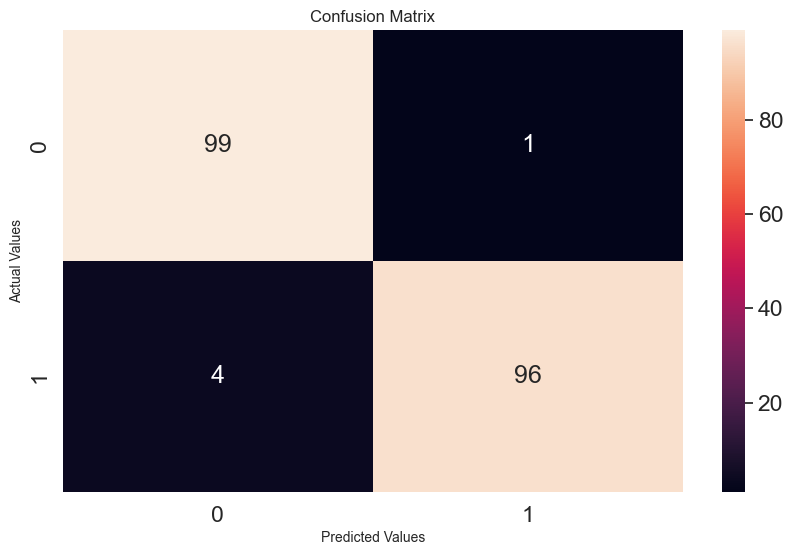

,Metric,Value
0,Accuracy Train,97.12
1,Accuracy Test,97.50
2,Precision Train,98.96
3,Precision Test,98.97
4,Recall Train,95.25
5,Recall Test,96.00
6,F1 Train,97.07
7,F1 Test,97.46
8,ROC AUC Train,99.34
9,ROC AUC Test,99.00


In [66]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

evaluate_model(
    lr_model,
    X_train,
    y_train,
    X_test,
    y_test
)

In [67]:
import pandas as pd

feature_importance_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
})

feature_importance_lr['Abs_Coefficient'] = (
    feature_importance_lr['Coefficient'].abs()
)

feature_importance_lr = feature_importance_lr.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

display(feature_importance_lr)

,Feature,Coefficient,Abs_Coefficient
0,Daily Time Spent on Site,-5.951746,5.951746
3,Daily Internet Usage,-5.605650,5.605650
2,Area Income,-3.454654,3.454654
1,Age,2.976679,2.976679
15,MonthName_March,-0.603619,0.603619
7,DayName_Sunday,0.470140,0.470140
14,MonthName_June,-0.326396,0.326396
4,Gender_Male,-0.297670,0.297670
8,DayName_Thursday,0.296057,0.296057
16,MonthName_May,0.259006,0.259006


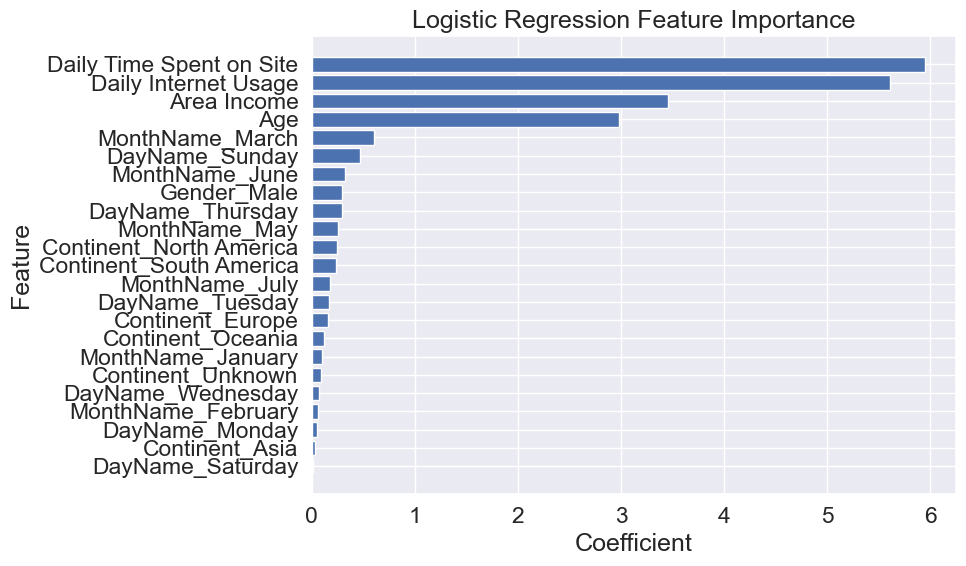

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_lr['Feature'],
    feature_importance_lr['Abs_Coefficient']
)

plt.gca().invert_yaxis()

plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Logistic Regression Feature Importance')

plt.tight_layout()
plt.show()

# Candidate Modelling

In [69]:
X = data_model.drop(columns=['Clicked on Ad','Gender','DayName','MonthName','Continent'])
y = data_model['Clicked on Ad']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_cols = ['Age', 'Daily Time Spent on Site', 'Daily Internet Usage', 'Area Income']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

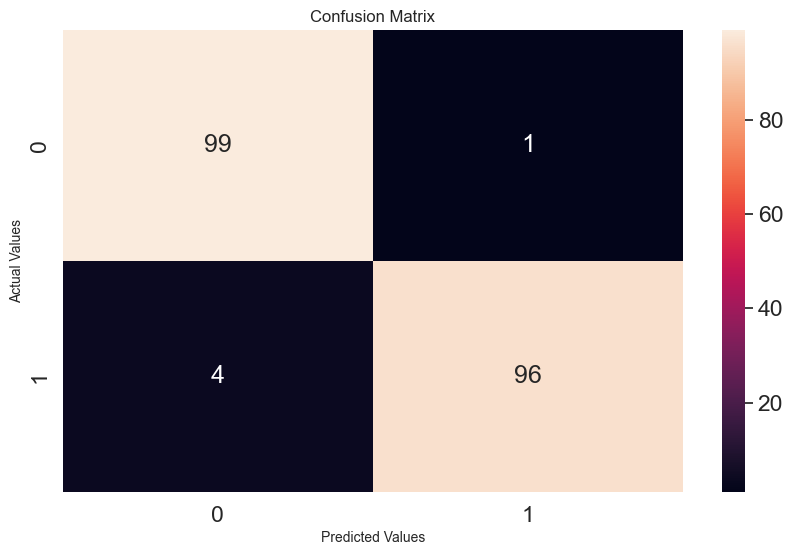

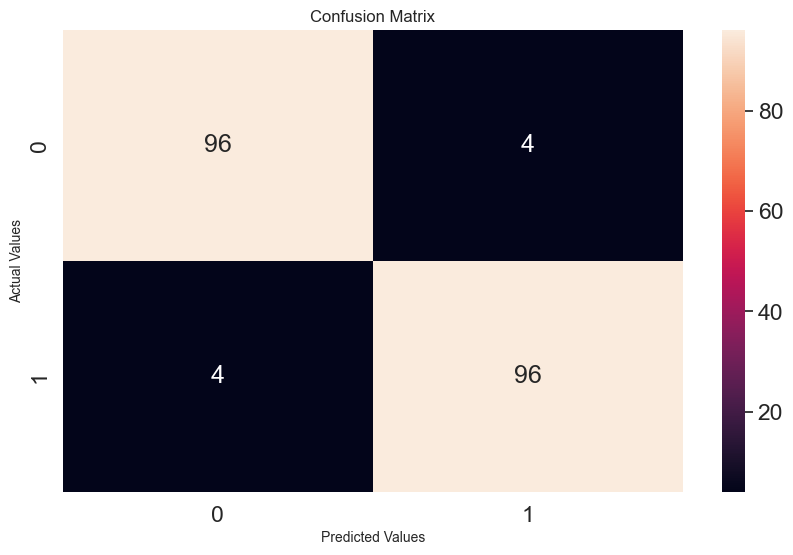

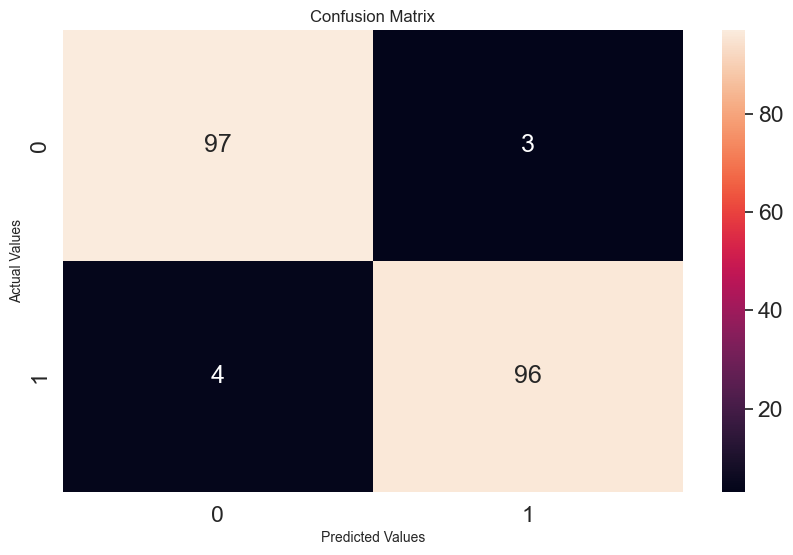

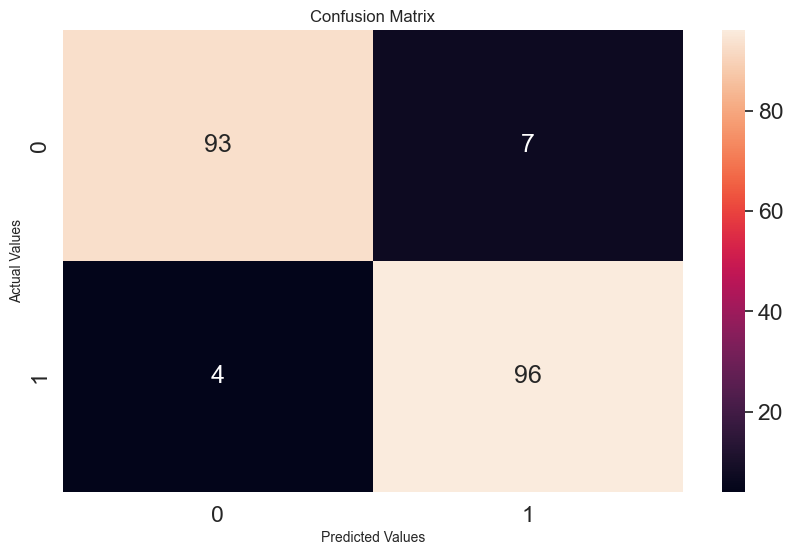

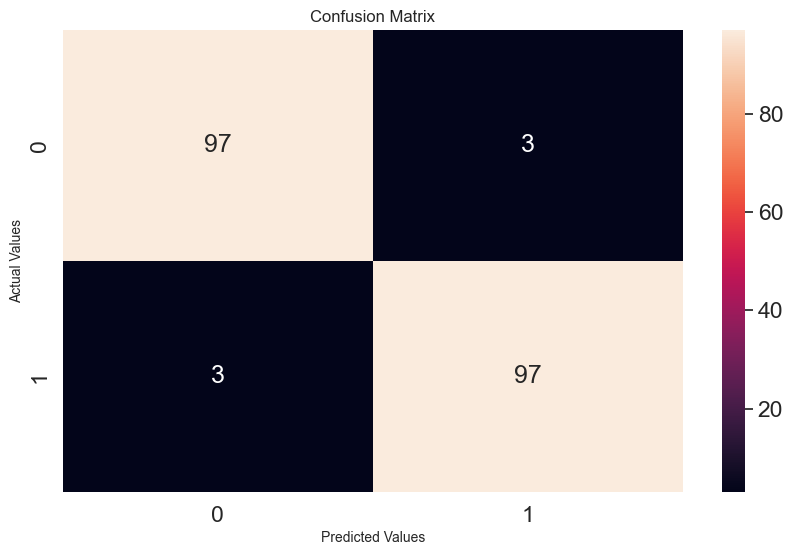

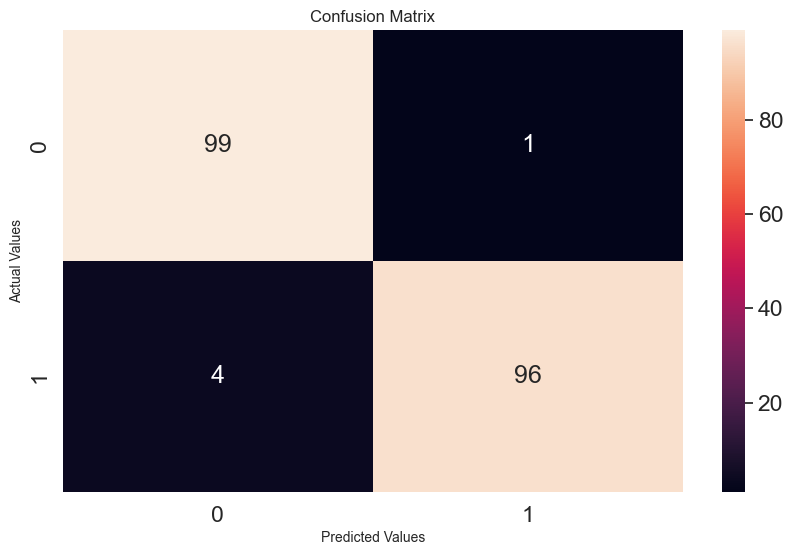

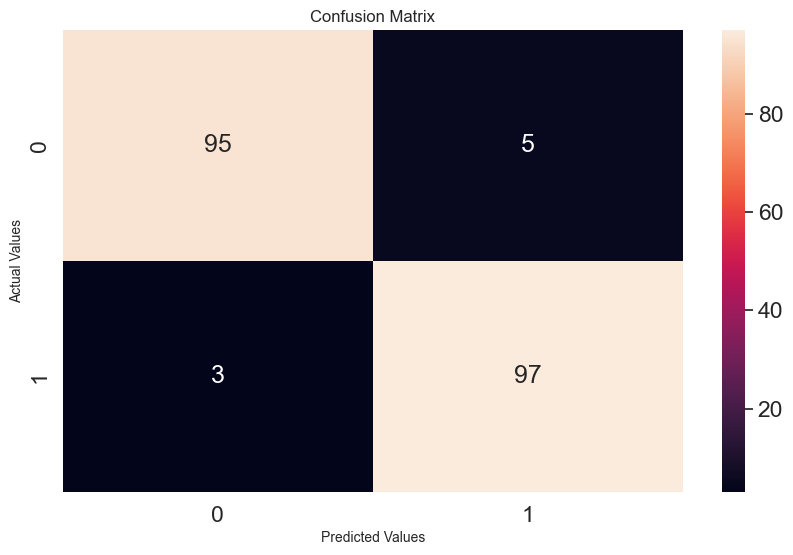

Metric,Model,Accuracy Train,Accuracy Test,Precision Train,Precision Test,Recall Train,Recall Test,F1 Train,F1 Test,ROC AUC Train,ROC AUC Test,CV Recall Train,CV Recall Test
0,Logistic Regression,96.50,97.5,98.69,98.97,94.25,96.0,96.42,97.46,99.09,99.16,94.31,94.25
1,Gradient Boosting,99.88,96.0,100.00,96.00,99.75,96.0,99.87,96.00,100.00,99.01,99.88,95.00
2,Random Forest,100.00,96.5,100.00,96.97,100.00,96.0,100.00,96.48,100.00,98.82,100.00,95.75
3,Decision Tree,100.00,94.5,100.00,93.20,100.00,96.0,100.00,94.58,100.00,94.50,100.00,94.25
4,SVM,97.12,97.0,97.96,97.00,96.25,97.0,97.10,97.00,99.43,98.87,96.31,95.75
5,KNN,96.75,97.5,97.95,98.97,95.50,96.0,96.71,97.46,99.69,98.84,95.06,94.00
6,XGBoost,100.00,96.0,100.00,95.10,100.00,97.0,100.00,96.04,100.00,99.31,100.00,94.50


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import pandas as pd

models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("Gradient Boosting", GradientBoostingClassifier()),
    ("Random Forest", RandomForestClassifier(random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("SVM", SVC(probability=True, random_state=42)),
    ("KNN", KNeighborsClassifier()),
    ("XGBoost", xgb.XGBClassifier(
        objective='binary:logistic',
        random_state=42
    ))
]

results = []

for model_name, model in models:

    result = evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test
    )

    result = result.set_index('Metric').T
    result.insert(0, 'Model', model_name)

    results.append(result)

candidate_results = pd.concat(results, ignore_index=True)

display(candidate_results)

# Tuned Selected Model

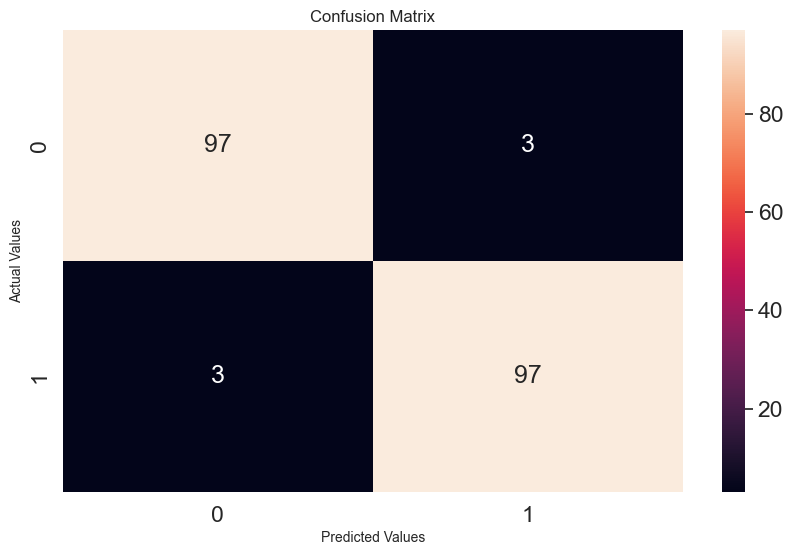

,Metric,Value
0,Accuracy Train,97.12
1,Accuracy Test,97.00
2,Precision Train,97.96
3,Precision Test,97.00
4,Recall Train,96.25
5,Recall Test,97.00
6,F1 Train,97.10
7,F1 Test,97.00
8,ROC AUC Train,99.43
9,ROC AUC Test,98.87


In [71]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

evaluate_model(
    svm_model,
    X_train,
    y_train,
    X_test,
    y_test
)

In [72]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

param_dist = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

svm = SVC(
    probability=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("Best CV Recall:")
print(random_search.best_score_)

Best Parameters:
{'kernel': 'rbf', 'gamma': 1, 'C': 10}
Best CV Recall:
0.96


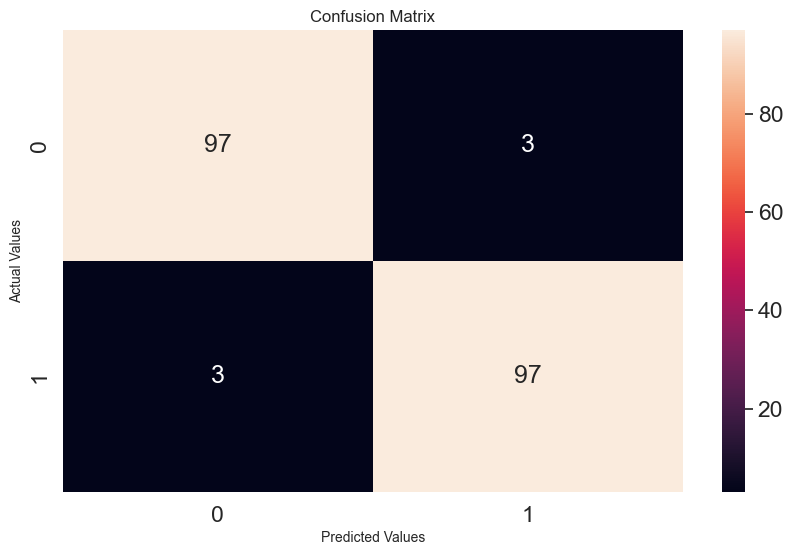

,Metric,Value
0,Accuracy Train,96.88
1,Accuracy Test,97.00
2,Precision Train,97.47
3,Precision Test,97.00
4,Recall Train,96.25
5,Recall Test,97.00
6,F1 Train,96.86
7,F1 Test,97.00
8,ROC AUC Train,99.42
9,ROC AUC Test,98.94


In [73]:
best_svm = random_search.best_estimator_

evaluate_model(
    best_svm,
    X_train,
    y_train,
    X_test,
    y_test
)

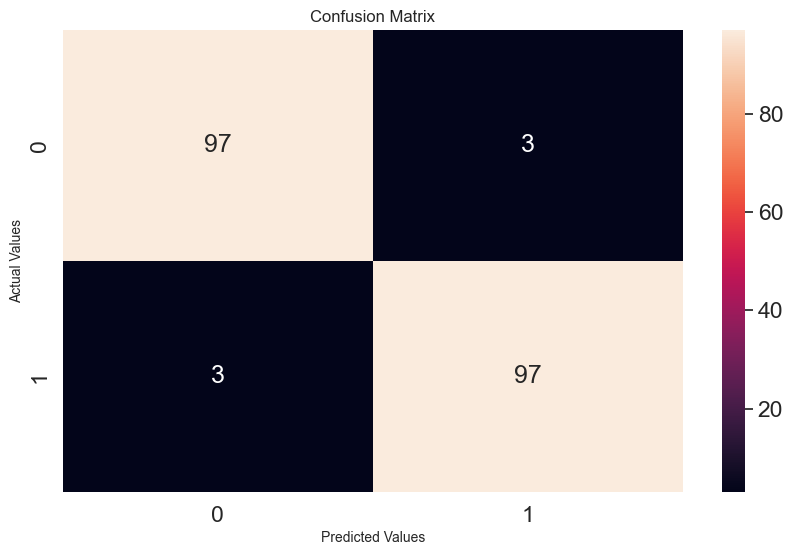

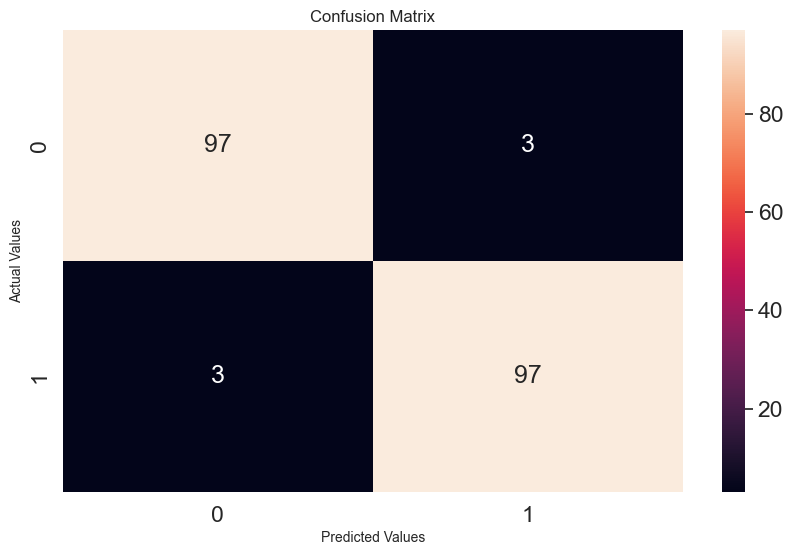

,Metric,SVM Before Tuning,SVM After Tuning
0,Accuracy Train,97.12,96.88
1,Accuracy Test,97.00,97.00
2,Precision Train,97.96,97.47
3,Precision Test,97.00,97.00
4,Recall Train,96.25,96.25
5,Recall Test,97.00,97.00
6,F1 Train,97.10,96.86
7,F1 Test,97.00,97.00
8,ROC AUC Train,99.43,99.42
9,ROC AUC Test,98.87,98.94


In [74]:
import pandas as pd

before_tuned = evaluate_model(
    svm_model,
    X_train,
    y_train,
    X_test,
    y_test
)

after_tuned = evaluate_model(
    best_svm,
    X_train,
    y_train,
    X_test,
    y_test
)

comparison = pd.DataFrame({
    'Metric': before_tuned['Metric'],
    'SVM Before Tuning': before_tuned['Value'],
    'SVM After Tuning': after_tuned['Value']
})

display(comparison)

In [75]:
import pandas as pd

cv_results = pd.DataFrame(random_search.cv_results_)

top5 = (
    cv_results
    .sort_values('mean_test_score', ascending=False)
    .head(5)
)

top5_table = pd.DataFrame({
    'Rank': range(1, 6),
    'C': top5['param_C'].values,
    'Gamma': top5['param_gamma'].values,
    'Kernel': top5['param_kernel'].values,
    'Mean CV Recall': top5['mean_test_score'].round(4).values
})

display(top5_table)

,Rank,C,Gamma,Kernel,Mean CV Recall
0,1,10.0,1,rbf,0.9600
1,2,100.0,auto,rbf,0.9600
2,3,1.0,scale,rbf,0.9575
3,4,100.0,0.1,rbf,0.9550
4,5,100.0,0.01,rbf,0.9525


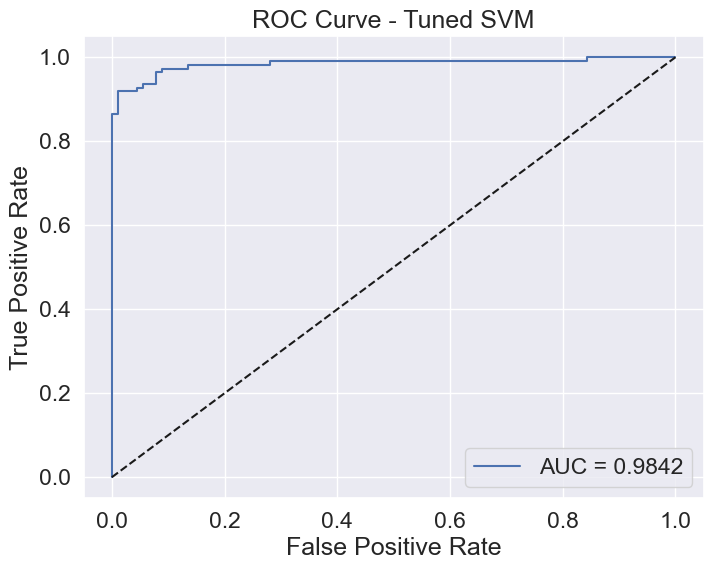

In [52]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = best_svm.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned SVM')
plt.legend()
plt.grid(True)

plt.show()

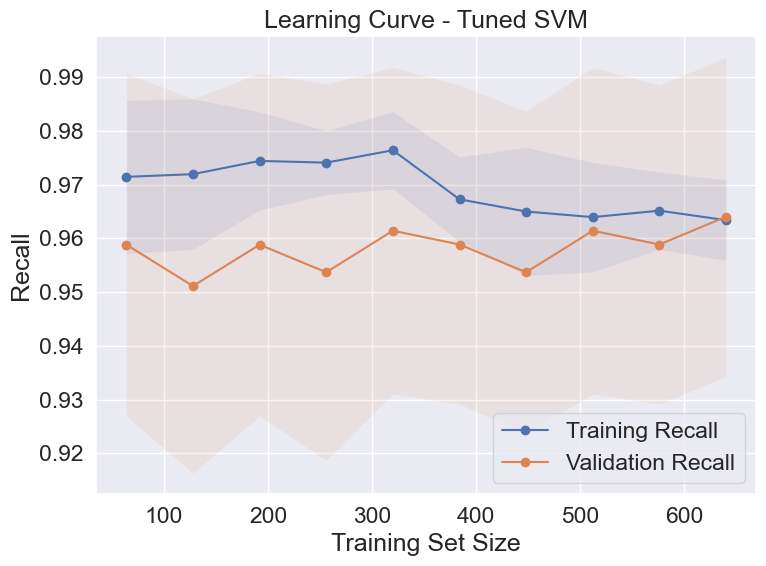

In [53]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_svm,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Recall'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation Recall'
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.1
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.1
)

plt.xlabel('Training Set Size')
plt.ylabel('Recall')
plt.title('Learning Curve - Tuned SVM')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()